### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, ConfusionMatrixDisplay

In [2]:
def load_data(filepath):
    df = pd.read_csv(filepath)
    return df

df = load_data(filepath='Dataset_Heart_Disease.csv')
df.head()

,Unnamed: 0,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [3]:
df.shape

(1048, 13)

In [5]:
df.describe()

,Unnamed: 0,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000
mean,390.841603,53.325382,0.734733,2.817748,132.613550,245.172710,0.162214,0.606870,142.918893,0.368321,0.942366,1.532443,0.496183
std,307.916633,9.397822,0.441686,1.118649,17.367605,57.101359,0.368823,0.763313,24.427115,0.482579,1.100429,0.611023,0.500224
min,0.000000,28.000000,0.000000,1.000000,92.000000,85.000000,0.000000,0.000000,69.000000,0.000000,-0.100000,0.000000,0.000000
25%,130.750000,46.000000,0.000000,2.000000,120.000000,208.000000,0.000000,0.000000,125.000000,0.000000,0.000000,1.000000,0.000000
50%,262.000000,54.000000,1.000000,3.000000,130.000000,239.000000,0.000000,0.000000,144.000000,0.000000,0.600000,2.000000,0.000000
75%,657.250000,60.000000,1.000000,4.000000,140.000000,275.000000,0.000000,1.000000,162.000000,1.000000,1.600000,2.000000,1.000000
max,1189.000000,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [7]:
df.isnull().sum()

Unnamed: 0             0
age                    0
sex                    0
chest pain type        0
resting bps            0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Unnamed: 0               int64
age                      int64
sex                      int64
chest pain type          int64
resting bps              int64
cholesterol              int64
fasting blood sugar      int64
resting ecg              int64
max heart rate           int64
exercise angina          int64
oldpeak                float64
ST slope                 int64
target                   int64
dtype: object

In [11]:
encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
df[['target']] = encoder.fit_transform(df[['target']]).astype(int)
df['target'].head(2)

0    0
1    1
Name: target, dtype: int64

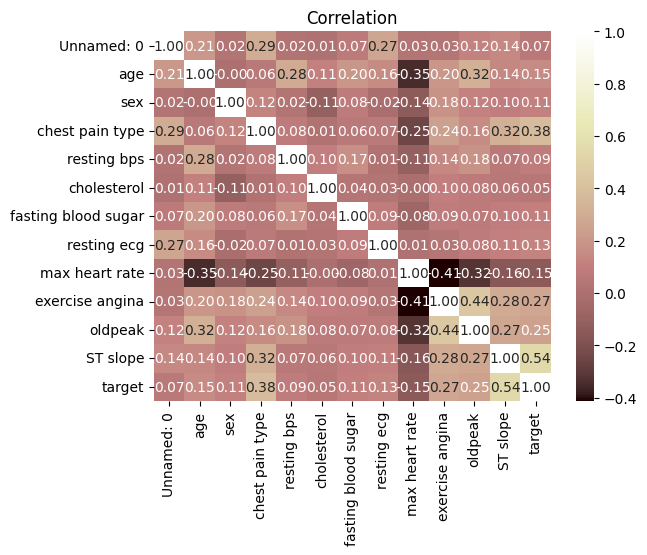

In [12]:
sns.heatmap(df.corr(method="spearman"), annot=True, cmap="pink", fmt=".2f")
plt.title("Correlation")
plt.show()

In [16]:
feature = df[['age','sex','chest pain type','resting bps','cholesterol','fasting blood sugar','resting ecg','max heart rate',
    'exercise angina','oldpeak','ST slope']]
target = df['target']

In [18]:
x_train, x_test, y_train, y_test = train_test_split(feature, target, stratify=target, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((786, 11), (262, 11), (786,), (262,))

In [19]:
x_tr_scaled = StandardScaler().fit_transform(x_train)
x_te_scaled = StandardScaler().fit_transform(x_test)
x_tr_scaled, x_te_scaled


(array([[ 0.69963278, -1.62446572,  0.15757738, ..., -0.76464202,
         -0.85402043,  0.75537533],
        [ 0.48457163, -1.62446572, -0.73992854, ..., -0.76464202,
         -0.85402043,  0.75537533],
        [-0.2681424 , -1.62446572,  1.05508329, ..., -0.76464202,
          0.03754559, -0.87573733],
        ...,
        [-0.2681424 , -1.62446572,  0.15757738, ..., -0.76464202,
         -0.40823742,  0.75537533],
        [ 0.37704106, -1.62446572,  1.05508329, ..., -0.76464202,
         -0.85402043, -0.87573733],
        [-1.23591759,  0.61558701, -0.73992854, ..., -0.76464202,
         -0.85402043, -0.87573733]], shape=(786, 11)),
 array([[ 0.1222003 ,  0.55677644, -1.59153413, ..., -0.7604691 ,
          0.29516338,  0.79695773],
        [ 0.43303989,  0.55677644,  1.06440181, ...,  1.31497782,
          2.04170104,  0.79695773],
        [-1.01754488,  0.55677644,  1.06440181, ..., -0.7604691 ,
         -0.86919506, -0.86020834],
        ...,
        [ 0.1222003 ,  0.55677644,  1

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
logistic_model = LogisticRegression(penalty=None, random_state=42)
logistic_model.fit(x_tr_scaled, y_train)

c:\Users\bidhi\OneDrive\Desktop\Lab1&2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver becaus

In [22]:
logistic_model.coef_

array([[ 0.26901019,  0.13734832,  0.57719346,  0.0130258 , -0.02289757,
         0.08171645,  0.07918484,  0.21560578,  0.26124916,  0.16225324,
         1.03182603]])

In [23]:
y_pred = logistic_model.predict(x_te_scaled)

In [24]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80       132
           1       0.80      0.78      0.79       130

    accuracy                           0.79       262
   macro avg       0.79      0.79      0.79       262
weighted avg       0.79      0.79      0.79       262



Confusion Matrix
[[107  25]
 [ 29 101]]


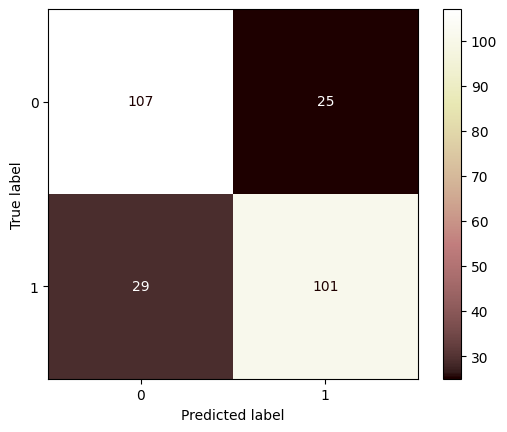

In [25]:
print("Confusion Matrix")
confusion_mat = confusion_matrix(y_true=y_test, y_pred=y_pred)
ConfusionMatrixDisplay(confusion_matrix=confusion_mat).plot(cmap="pink")
print(confusion_mat)

In [26]:
y_score = logistic_model.predict_proba(x_te_scaled)[:,1]

Average Precision Score: 0.838


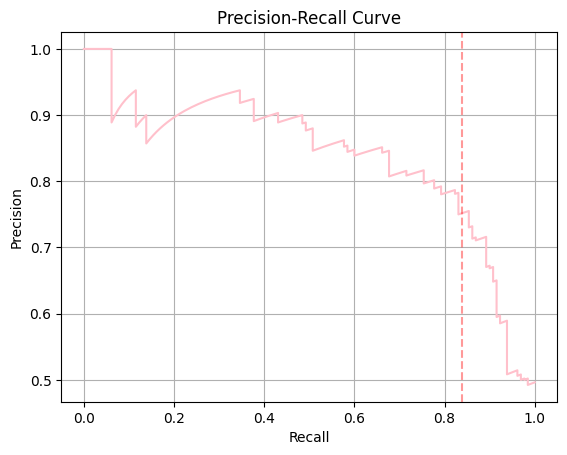

In [28]:
precision, recall, threshold = precision_recall_curve(y_test, y_score)
pr_auc = average_precision_score(y_test, y_score)
plt.plot(recall, precision, color='pink')
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axvline(pr_auc, color='r', alpha=0.4, linestyle='--')
print(f"Average Precision Score: {pr_auc:.3f}")